# MiniGPT — Training

In [1]:
from src.config import Config
from src.utils import set_seed, initialize_weights, count_parameters, plot_loss_curve
from src.data import prepare_data, preprocess_text, get_batch
from src.model import MiniGPT
from src.train import train_model

config = Config()
device = config.device
print("Device:", device)

Device: cuda


In [13]:
config.block_size = 256
config.embedding_dim = 384
config.n_head = 12
config.n_layer = 12

config.batch_size = 64
config.max_iters = 20000
config.eval_interval = 250
config.eval_iters = 100

print(config)
print("Device:", config.device)

Config(data_path='data/input.txt', model_dir='models', checkpoint_name='mini_gpt_checkpoint.pth', best_model_name='mini_gpt_best.pth', data_fraction=1, train_split=0.9, block_size=256, embedding_dim=384, n_head=12, n_layer=12, dropout=0.0, batch_size=64, learning_rate=0.0002, weight_decay=0.01, max_iters=20000, eval_interval=250, eval_iters=100, seed=42)
Device: cuda


In [3]:
set_seed(config.seed)

text, tokenizer, train_data, val_data = prepare_data(
    path="data/input.txt",
    fraction=config.data_fraction,
    train_split=config.train_split
)

Original length: 227566049
Cleaned length: 226462031
Vocabulary size: 70
['\n', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', '?', '@', '[', '\\', ']', '^', '_', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '|', '}', '~']
Train characters: 203815827
Validation characters: 22646204


In [14]:
model = MiniGPT(
    vocab_size=tokenizer.vocab_size,
    block_size=config.block_size,
    embedding_dim=config.embedding_dim,
    n_head=config.n_head,
    n_layer=config.n_layer,
    dropout=config.dropout
).to(config.device)

model.apply(initialize_weights)
summary = count_parameters(model)

Total trainable parameters: 21,432,576
Total parameters in millions: 21.43M

---------------------------------------------------------------------------
embedding.token_embedding.weight                                 26,880
embedding.position_embedding.weight                              98,304
blocks.0.ln1.weight                                                 384
blocks.0.ln1.bias                                                   384
blocks.0.attention.heads.0.query.weight                          12,288
blocks.0.attention.heads.0.key.weight                            12,288
blocks.0.attention.heads.0.value.weight                          12,288
blocks.0.attention.heads.1.query.weight                          12,288
blocks.0.attention.heads.1.key.weight                            12,288
blocks.0.attention.heads.1.value.weight                          12,288
blocks.0.attention.heads.2.query.weight                          12,288
blocks.0.attention.heads.2.key.weight                  

In [15]:
x, y = get_batch(
    train_data,
    config.batch_size,
    config.block_size,
    config.device
)

logits = model(x)

print("Input shape :", x.shape)
print("Target shape:", y.shape)
print("Logits shape:", logits.shape)

Input shape : torch.Size([64, 256])
Target shape: torch.Size([64, 256])
Logits shape: torch.Size([64, 256, 70])


In [16]:
results = train_model(
    model=model,
    train_data=train_data,
    val_data=val_data,
    config=config,
    tokenizer=tokenizer
)

Iteration     1 | Train Loss: 3.6782 | Val Loss: 3.6711
  Saved best model -> models/mini_gpt_best.pth
Iteration   250 | Train Loss: 2.4365 | Val Loss: 2.4167
  Saved best model -> models/mini_gpt_best.pth
Iteration   500 | Train Loss: 2.3930 | Val Loss: 2.3720
  Saved best model -> models/mini_gpt_best.pth
Iteration   750 | Train Loss: 2.3516 | Val Loss: 2.3362
  Saved best model -> models/mini_gpt_best.pth
Iteration  1000 | Train Loss: 2.3306 | Val Loss: 2.3078
  Saved best model -> models/mini_gpt_best.pth
Iteration  1250 | Train Loss: 2.3063 | Val Loss: 2.2875
  Saved best model -> models/mini_gpt_best.pth
Iteration  1500 | Train Loss: 2.3078 | Val Loss: 2.2881
Iteration  1750 | Train Loss: 2.2848 | Val Loss: 2.2669
  Saved best model -> models/mini_gpt_best.pth
Iteration  2000 | Train Loss: 3.0439 | Val Loss: 3.0181
Iteration  2250 | Train Loss: 2.4355 | Val Loss: 2.4156
Iteration  2500 | Train Loss: 2.3636 | Val Loss: 2.3485
Iteration  2750 | Train Loss: 2.3544 | Val Loss: 2.3370

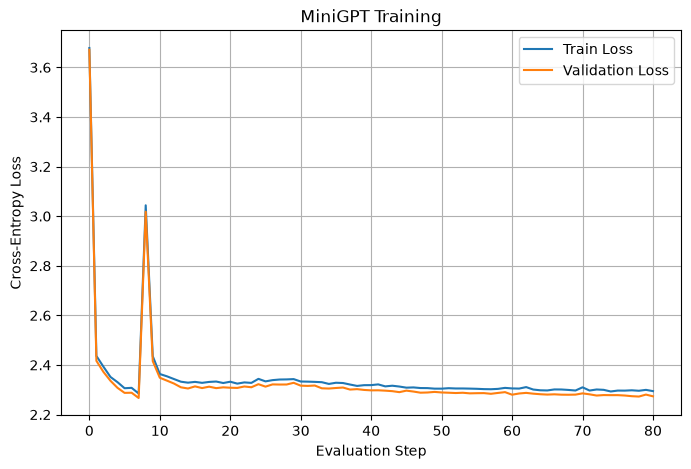

In [17]:
plot_loss_curve(
    results["train_losses"],
    results["val_losses"]
)

## Final evaluation of the best checkpoint

In [18]:
from src.utils import load_checkpoint, perplexity
import torch.nn as nn

best_model, best_checkpoint = load_checkpoint(
    config.best_model_path,
    MiniGPT,
    config.device
)

loss_fn = nn.CrossEntropyLoss()

final_losses = __import__("src.train", fromlist=["estimate_loss"]).estimate_loss(
    best_model,
    train_data,
    val_data,
    loss_fn,
    config.batch_size,
    config.block_size,
    config.device,
    config.eval_iters
)

print(f"Train Loss: {final_losses['train']:.4f}")
print(f"Val Loss  : {final_losses['val']:.4f}")
print(f"Train Perplexity: {perplexity(final_losses['train']):.2f}")
print(f"Val Perplexity  : {perplexity(final_losses['val']):.2f}")

Train Loss: 2.2848
Val Loss  : 2.2651
Train Perplexity: 9.82
Val Perplexity  : 9.63
